In [11]:
import matplotlib.pyplot as plt #用于专用绘图函数
import itertools #迭代器,python内置模块
import numpy as np
import matplotlib as mpl #用于访问配置项
import seaborn as sns
import string #进行字符串操作
from scipy.spatial import distance_matrix #计算多点之间成对组合的距离 接受数组和列表,计算梅两个点之间的距离返回矩阵,每个元素为距离值
from scipy.spatial.distance import euclidean #欧氏距离
import os

if not os.path.isdir('Figures'):
    os.makedirs('Figures')

In [13]:
num = 26
np.random.seed(0)
#在0-10之间生成随机数,形状为26行2列 左闭右开,没写左边的书代表是0,默认low为0
#如果为负数必须写0 因为low默认为0报错
data = np.random.randint(10 + 1,size=(num,2)) 
#生成A-Z的大写字母将其转换为列表
#string.ascii_uppercase是一个串字符串,有A-Z的大写字母.list将其变成可迭代列表
labels = list(string.ascii_uppercase)

In [15]:
cmap = mpl.cm.get_cmap('RdYlBu_r') #_r表示红换蓝反向呈现从大到小 比如使用[1,0] 以前是[0,1]对应映射颜色

/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_76804/2105916186.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdYlBu_r') #_r表示红换蓝反向呈现从大到小 比如使用[1,0] 以前是[0,1]对应映射颜色


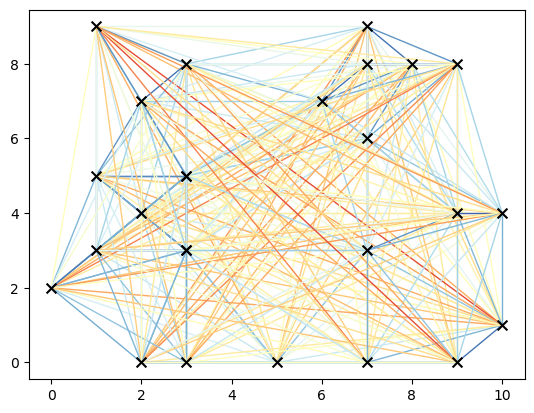

In [21]:
fig, ax = plt.subplots()
#里面的函数为一种特殊迭代器,取出所有可能组合,不重复 返回元组 每一次的返回的元组带索引 例子:(data[0],data[2])
# enumerate是python自带函数,无需导入.返回一个迭代器,迭代器每一次都将赋予到i和d仅仅是一对值,会对应位置赋值即可
for i,d in enumerate(itertools.combinations(data,2)):
    #计算2点之间的欧氏距离
    d_idx = euclidean(d[0],d[1])
    #画出这一对中的亮点连线,
    plt.plot([d[0][0],d[1][0]], #x1 x2
            [d[0][1],d[1][1]], #y1 y2
             #因为整个图的对角线距离是最大距离10*√2 所以除以这个值
            color = cmap(d_idx/np.sqrt(2)/10),lw = 1)
ax.scatter(data[:,0],data[:,1], #所有的x和y点
           marker = 'x',color = 'k',s = 50,zorder=100)

<Axes: >

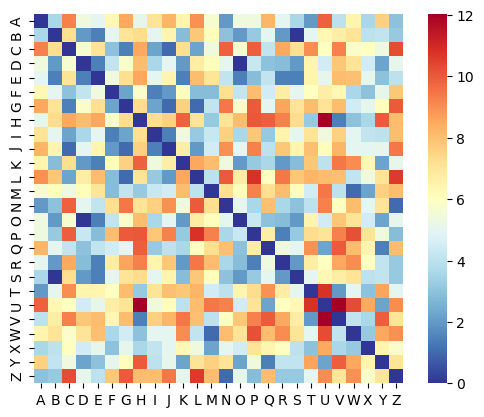

In [23]:
pairwise_distances = distance_matrix(data,data)
fig,ax = plt.subplots()
sns.heatmap(pairwise_distances,
            cmap = 'RdYlBu_r',square = True,
            xticklabels = labels,yticklabels = labels,
            ax=ax)

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import string
from scipy.spatial import distance_matrix

In [27]:
num = 26
np.random.seed(0)
data = np.random.randint(10+1,size=(num,2))
labels = list(string.ascii_uppercase)

In [33]:
pairwise_df = distance_matrix(data,data)

In [37]:
#创建面具 过滤矩阵
#用ones_like1创建与矩阵相同的全为1的bool(布尔矩阵) 所有元素为True 使用ones_like直接创建形状相同矩阵
#triu 表示triangle upper   numpy中的函数,取上三角矩阵包含对角线,并将下三角函数设为0
mask = np.triu(np.ones_like(pairwise_df,dtype=bool))

<Axes: >

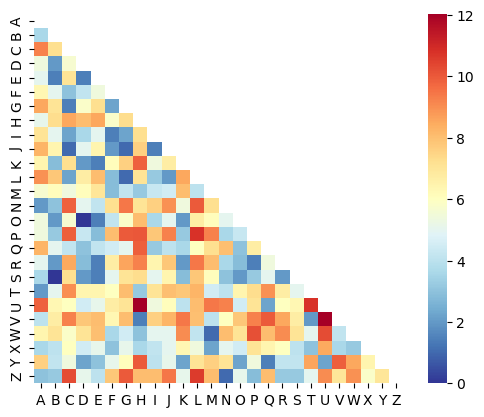

In [39]:
fig,ax = plt.subplots()
sns.heatmap(pairwise_df,
            #因为为面具对应mask中的矩阵值 为1的将会被舍弃
            mask = mask,
            cmap = 'RdYlBu_r',
            square = True,
            xticklabels = labels,
            yticklabels = labels,
            ax=ax)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d #导入一维插值函数

In [5]:
np.random.seed(8)
x = np.linspace(0,10,10) #闭区间包含0和10 线性间隔 第一个点为0的位置低10个点在10的位置,但是第二个点值为1.111...
y = np.random.rand(10)*10 #rand是random缩写生成[0,10]的随机数
x_fine = np.linspace(0,10,1001)

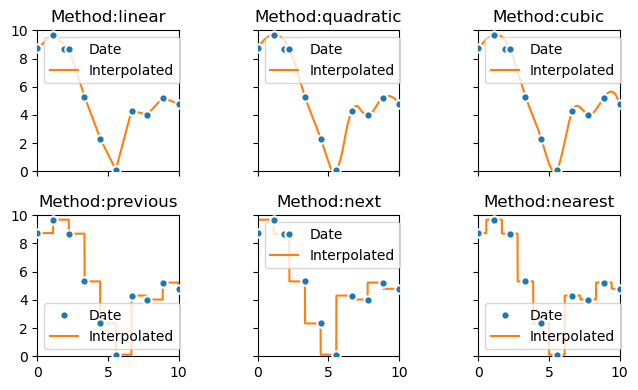

In [39]:
fig,axes = plt.subplots(2,3,figsize=(7,4),
                       sharex = 'col',
                       sharey = 'row')
#将多维数组转换为一维数组,意思是将其展平为一维数组
#方便for循环处理
#管是flatten怎么展开,都按照以前的布局生效,分享的xy显示效果不变,因为函数还是在原来排序的位置
axes = axes.flatten() #
methods = ['linear','quadratic','cubic',
           'previous','next','nearest']

for i,method in enumerate(methods): #迭代器,返回两个值付给两个变量i是用来计数的

    #创建interp1d对象 interp是插值inperpolate缩写
    #f是一个函数对象 由interp1d创建的插值函数,不会立即插值,是先创建了一个可调用函数f,记住了x,y和插值方式
    #一开始为矩阵2x3的结构是为了访问矩阵如axes[2,3]一下子就知道是第二行第三列上的对象,一维虽然也能支持,但不明确
    #二维不好遍历,变成一维更好遍历
    f = interp1d(x,y,kind = method)
    #生成插值的数据点
    #这里x_fine是实参传递进入f
    y_fine = f(x_fine)

    #绘制子图
    axes[i].plot(x,y,'o',label='Date',
                markeredgewidth = 1.5,markeredgecolor = 'w',zorder = 100)#层级为100
    axes[i].plot(x_fine,y_fine,label = 'Interpolated')#表示插值的线的标签
    axes[i].set_title(f'Method:{method}')
    axes[i].legend()#有图例的意思,地图中表示解释符号或者颜色
    axes[i].set_xlim(0,10)
    axes[i].set_ylim(0,10)
    axes[i].set_aspect('equal',adjustable='box')
plt.tight_layout()#自动调整间距,放置标签标题重叠,不是显示函数,后面需要跟着show()

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import norm #scipy.stats(统计学) 导入norm子模块(进行一元正态分布)

In [47]:
x_array = np.linspace(-6,6,200)
mu_array = np.linspace(-4,4,9)

In [57]:
#生成颜色对应数列 cm下的对应颜色值根据0-1范围内的值将其转换成特定RGBA值用于显示
#生成的数列形状为9,4 每一行中的4个元素对应RGBA 每一行为一种颜色,根据前面的对应数值创建了9个
#只能接受0-1的数据值进行颜色映射 是闭区间
colors = cm.RdYlBu(np.linspace(0,1,len(mu_array)))

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_16619/597103632.py:4: SyntaxWarning: invalid escape sequence '\m'
  legend_idx = '$\mu$ = ' + str(mu_idx) #这里使用$调用特殊符号,这里特殊符号为μ


Text(0, 0.5, 'PDF $f_X(x)$')

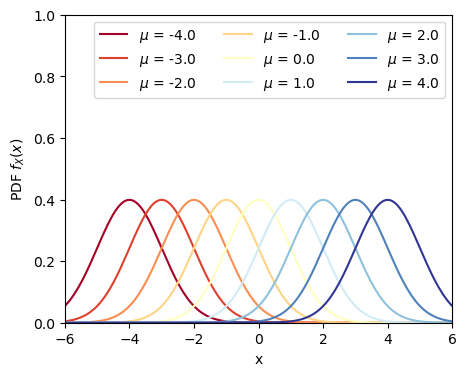

In [69]:
fig , ax = plt.subplots(figsize = (5,4))
for idx,mu_idx in enumerate(mu_array):
    pdf_idx = norm.pdf(x_array,scale = 1,loc = mu_idx) #三个形参:计算数值总量,标准差,均值
    legend_idx = '$\mu$ = ' + str(mu_idx) #这里使用$调用特殊符号,这里特殊符号为μ
    plt.plot(x_array,pdf_idx,color = colors[idx],label = legend_idx)

plt.legend(ncol=3)#配置列数
ax.set_xlim(x_array.min(),x_array.max())
ax.set_ylim(0,1)
ax.set_xlabel('x')
ax.set_ylabel('PDF $f_X(x)$')

In [71]:
sigma_array = np.linspace(0.5,5,10)

In [73]:
colors = cm.RdYlBu(np.linspace(0,1,len(sigma_array)))

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_16619/3705230196.py:4: SyntaxWarning: invalid escape sequence '\s'
  legend_idx = '$\sigma$ = ' +str(sigma_idx)


Text(0, 0.5, 'PDF, $f_X(x)$')

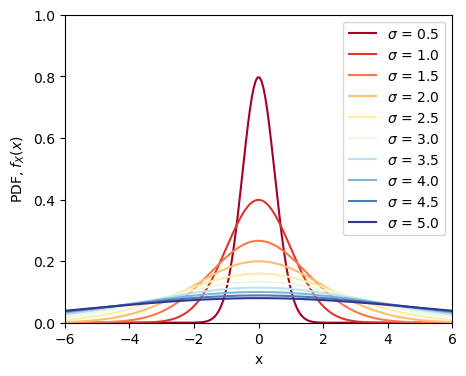

In [101]:
fig,ax = plt.subplots(figsize = (5,4))
for idx,sigma_idx in enumerate(sigma_array):
    pdf_idx = norm.pdf(x_array,scale = sigma_idx)
    legend_idx = '$\sigma$ = ' +str(sigma_idx)
    plt.plot(x_array,pdf_idx,color = colors[idx],label = legend_idx)

plt.legend()
ax.set_xlim(x_array.min(),x_array.max())
ax.set_ylim(0,1)
ax.set_xlabel('x')
ax.set_ylabel('PDF, $f_X(x)$')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal